# Import Required Libraries
Import necessary libraries for data processing, regex pattern matching, transformer models, and visualization.

In [1]:
# Import Required Libraries

# Data processing libraries
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
import torch
import json

# Regex pattern matching
import re

# Transformer models
from transformers import pipeline
from datasets import Dataset

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for plots
sns.set(style="whitegrid")

# Set default plt font size and typeface to times
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times New Roman'})

# Load and Prepare Data
Load the JSON file containing the walkability-relevant abstracts (output of the screening pipeline), extract the introductions, and perform basic cleaning operations.

In [2]:
# Load the JSON file containing screened walkability abstracts using pandas
import pandas as pd

# Load data with pandas
df = pd.read_json("../data/05_filtered_walkability_applications.json")

# Print count for verification
print(f"Total articles processed: {len(df)}")

Total articles processed: 968


# Define Walkability Dimensions (Alfonzo's Hierarchy of Walking Needs)
Create a dictionary of walkability dimensions — feasibility, accessibility, safety, comfort, and pleasurability — each broken down into operational subdomains drawn from the expanded instrument review.

In [3]:
# Load the JSON file with walkability dimensions
with open('../data/config/walkability_dimensions_extended.json', 'r') as f:
    walkability_dimensions = json.load(f)

# Flatten the hierarchy into subdomain labels with their context
flattened_dimensions = {}
for main_dimension, subdomains in walkability_dimensions.items():
    for subdomain in subdomains:
        # Create a key-value pair where the subdomain is the key
        # and includes context about its parent dimension
        flattened_dimensions[subdomain] = f"{subdomain} (part of {main_dimension})"

# Create labels list from subdomains
labels = list(flattened_dimensions.keys())

# Print the number of dimensions and some example labels
print(f"Total number of subdomains: {len(labels)}")
print(f"Example subdomains: {labels[:5]}")

Total number of subdomains: 62
Example subdomains: ['Sidewalk Provision', 'Path Continuity', 'Effective Walking Width', 'Surface Condition', 'Surface Evenness']


> **Note:** `walkability_dimensions_extended.json` here is a draft built from Alfonzo's (2005)
> hierarchy of walking needs plus common facets used in established walkability audit
> instruments (MAPS, PEDS, SWEAT, NEWS, and similar). It is **not** the definitive 46-instrument
> breakdown from the expanded review — replace/extend the subdomain lists per macro dimension
> with the actual instrument set before treating results as final. The rest of the pipeline
> (classification, thresholding, macro-domain assignment, saving) does not need to change if
> the subdomain lists are edited — only the config file does.

# Build Transformer Model
Initialize a pre-trained transformer model and set up a zero-shot, multi-label classification approach.

In [4]:
# Build Transformer Model for Zero-Shot Classification
# model = "facebook/bart-large-mnli"
model = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0-c"

# Set tokenizers parallelism
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Check available devices
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

# Set device for Apple Silicon
if torch.backends.mps.is_available():
    device = "mps"
    print("Using MPS (Metal Performance Shaders)")
elif torch.cuda.is_available():
    device = 0
    print("Using CUDA GPU")
else:
    device = -1
    print("Using CPU")


device = torch.device(device)

# Initialize the classifier with device setting
try:
    classifier = pipeline(
        "zero-shot-classification", model=model, device=device, multi_label=True
    )
    print("Classifier initialized successfully")
except Exception as e:
    print(f"Error initializing with {device}, falling back to CPU")
    device = -1
    classifier = pipeline(
        "zero-shot-classification", model=model, device=device, multi_label=True
    )

# Function to classify sentences into walkability dimensions
def classify_sentences(sentences, labels):
    results = []
    for sentence in tqdm(sentences):
        if sentence:  # Check if sentence is not empty
            try:
                result = classifier(
                    sentence,
                    candidate_labels=labels,
                    hypothesis_template="This text is about {}.",
                )
                results.append(result)
            except Exception as e:
                print(f"Error processing sentence: {str(e)}")
                results.append(None)
    return results

CUDA available: True
MPS available: False
Using CUDA GPU


Device set to use cuda:0


Classifier initialized successfully


In [5]:
# Test with a single sentence first
test_sentence = ("This study uses street-view imagery and a deep learning segmentation model "
                  "to automatically audit sidewalk width, curb ramps, and surface condition "
                  "across an entire city, providing a scalable alternative to manual field audits.")
print("\nTesting single classification...")
test_result = classifier(
    test_sentence, candidate_labels=labels, multi_label=True, hypothesis_template="This text is about {}."
)
print("Test successful!")
print(f"Result: {test_result}")


Testing single classification...


Test successful!
Result: {'sequence': 'This study uses street-view imagery and a deep learning segmentation model to automatically audit sidewalk width, curb ramps, and surface condition across an entire city, providing a scalable alternative to manual field audits.', 'labels': ['Pedestrian Space Adequacy', 'Route Traversability', 'Curb Ramps', 'Streetscape Coherence', 'Street Liveliness', 'Maintenance and Upkeep', 'Surface Condition', 'Visual Quality', 'Sidewalk Crowding', 'Imageability', 'Obstruction and Blockage', 'Pedestrian Signals', 'Path Continuity', 'Enclosure and Proportion', 'Sidewalk Provision', 'Vehicle-Pedestrian Separation', 'Multimodal Access', 'Effective Walking Width', 'Surface Evenness', 'Step-Free Transition', 'Facility Reachability', 'Human-Scale Design', 'Street Network Connectivity', 'Sight Lines and Visibility', 'Crossing Protection', 'Active Frontages', 'Street Furniture', 'Destination Proximity', 'Vertical Barriers', 'Land Use Mix', 'Visual Diversity and Comple

# Classify Abstract Introductions
Use the transformer model to classify the introductions into the defined walkability dimensions.

In [6]:
# Filter to keep only rows with non-empty introductions
df_filtered = df[df['introduction'].str.strip().astype(bool)].copy()

# Process the filtered dataset
print(f"\nClassifying introductions from {len(df_filtered)} abstracts...")

# Create a dataset from the DataFrame for more efficient processing
dataset = Dataset.from_pandas(df_filtered[['introduction']])

# Create classification function that handles batches
def classify_batch(batch):
    try:
        results = classifier(
            batch['introduction'],
            candidate_labels=labels,
            hypothesis_template="This text is about {}.",
            batch_size=8  # Adjust based on your GPU memory
        )

        # Extract and store classifications
        batch['classification_labels'] = [result['labels'] for result in results]
        batch['classification_scores'] = [result['scores'] for result in results]
        return batch
    except Exception as e:
        print(f"Error processing batch: {str(e)}")
        return batch

# Process the dataset with batching and show progress bar
processed_dataset = dataset.map(
    classify_batch,
    batched=True,
    batch_size=16,  # Adjust based on your GPU memory
    desc="Classifying"
)

# Convert processed dataset back to DataFrame
results_df = processed_dataset.to_pandas()

# Merge results back to original DataFrame
df_filtered['classification_labels'] = results_df['classification_labels']
df_filtered['classification_scores'] = results_df['classification_scores']

# Count valid results
valid_results = df_filtered['classification_labels'].notna().sum()
print(f"\nSuccessfully classified {valid_results} out of {len(df_filtered)} introductions")


Classifying introductions from 968 abstracts...


Classifying:   0%|          | 0/968 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Successfully classified 968 out of 968 introductions


In [7]:
# Display example classifications
print("\nExample classifications:")
# Sample 5 random rows to showcase classifications
for i, (_, row) in enumerate(df_filtered.sample(min(5, len(df_filtered))).iterrows()):
    print(f"\nAbstract {i+1} (DOI: {row['doi']}):")
    print(f"Introduction (truncated): {row['introduction'][:200]}...")
    print("Top 3 subdomains:")
    for label, score in zip(
        row["classification_labels"][:3],
        row["classification_scores"][:3]
    ):
        print(f"  - {label}: {score:.4f}")


Example classifications:

Abstract 1 (DOI: 10.1016/j.compenvurbsys.2026.102480):
Introduction (truncated): The 15-min city concept promises equitable access to essential services through walkable neighborhoods, yet traditional accessibility assessments fail to capture the dynamic impact of vehicular exposu...
Top 3 subdomains:
  - Walking Distance to Amenities: 0.9859
  - Pedestrian Space Adequacy: 0.6174
  - Vehicle-Pedestrian Separation: 0.3331

Abstract 2 (DOI: 10.1016/j.compenvurbsys.2024.102151):
Introduction (truncated): China is on the brink of transitioning into an aged society, resulting in a growing demand for an age-friendly street-built environment. However, previous research has paid limited attention to the di...
Top 3 subdomains:
  - Pedestrian Space Adequacy: 0.8226
  - Street Liveliness: 0.7631
  - Walking Distance to Amenities: 0.7242

Abstract 3 (DOI: 10.1080/13574809.2026.2655850):
Introduction (truncated): The study examines the relationship between street vitalit

# Evaluate Results

## Evaluate statistics of scores to determine the threshold

In [8]:
# Extract the statistics for the scores

# Create a dictionary to store scores for each subdomain
domain_scores = {domain: [] for domain in labels}

# Process each row in the DataFrame
for _, row in df_filtered.iterrows():
    # Check if classification data exists
    if 'classification_labels' in row and not pd.isna(row['classification_labels']).any():
        # Get the top 5 labels and scores
        top_labels = row['classification_labels'][:5]
        top_scores = row['classification_scores'][:5]

        # Add scores to the corresponding subdomains
        for label, score in zip(top_labels, top_scores):
            if label in domain_scores:
                domain_scores[label].append(score)

# Display the average scores for each subdomain
print("\n📊 Average Scores per Subdomain:")

# Calculate the average score for each subdomain
average_scores = {domain: np.mean(scores) if scores else np.nan for domain, scores in domain_scores.items()}

# Sort subdomains by average score and display
for domain, score in sorted(average_scores.items(), key=lambda x: x[1] if not np.isnan(x[1]) else -1, reverse=True):
    if not np.isnan(score):
        print(f"  - {domain}: {score:.4f}")

# Find the maximum length of score lists
max_len = max((len(scores) for scores in domain_scores.values() if scores), default=0)

# Pad shorter lists with NaN values for visualization
for domain, scores in domain_scores.items():
    if len(scores) < max_len:
        scores.extend([np.nan] * (max_len - len(scores)))

# Build a DataFrame for the violin plot below
scores_df = pd.DataFrame(domain_scores)


📊 Average Scores per Subdomain:
  - Tactile Paving: 0.8080
  - Air Quality: 0.6893
  - Thermal Comfort: 0.6541
  - Street Lighting: 0.6375
  - Traffic Speed: 0.5743
  - Streetscape Aesthetics: 0.5273
  - Pedestrian Space Adequacy: 0.4975
  - Greenery and Vegetation: 0.4784
  - Route Choice: 0.4668
  - Pedestrian Crash Exposure: 0.4585
  - Street Liveliness: 0.4541
  - Public Transit Access: 0.4508
  - Visual Quality: 0.4379
  - Pedestrian Signals: 0.4331
  - Sidewalk Crowding: 0.3904
  - Noise Levels: 0.3858
  - Walking Distance to Amenities: 0.3746
  - Sight Lines and Visibility: 0.3742
  - Street Furniture: 0.3620
  - Building Facade Quality: 0.3581
  - Perceived Safety: 0.3416
  - Sidewalk Provision: 0.3411
  - Crossing Protection: 0.3200
  - Multimodal Access: 0.3167
  - Weather Protection: 0.3093
  - Shade and Tree Canopy: 0.2983
  - Streetscape Coherence: 0.2721
  - Imageability: 0.2554
  - Street Network Connectivity: 0.2366
  - Seating and Resting Places: 0.2363
  - Route Trav


📏 Possible Thresholds:
  - fixed_conservative: 0.5000
  - fixed_liberal: 0.3000
  - mean: 0.2587
  - median: 0.0947
  - percentile_25: 0.0324
  - percentile_75: 0.4225
  - mean_minus_std: -0.0487

📊 Subdomains Assigned per Abstract with Different Thresholds:
  - fixed_conservative (threshold=0.5000): 1.13 subdomains per abstract
  - fixed_liberal (threshold=0.3000): 1.62 subdomains per abstract
  - mean (threshold=0.2587): 1.76 subdomains per abstract
  - median (threshold=0.0947): 3.08 subdomains per abstract
  - percentile_25 (threshold=0.0324): 6.28 subdomains per abstract
  - percentile_75 (threshold=0.4225): 1.29 subdomains per abstract
  - mean_minus_std (threshold=-0.0487): 62.00 subdomains per abstract


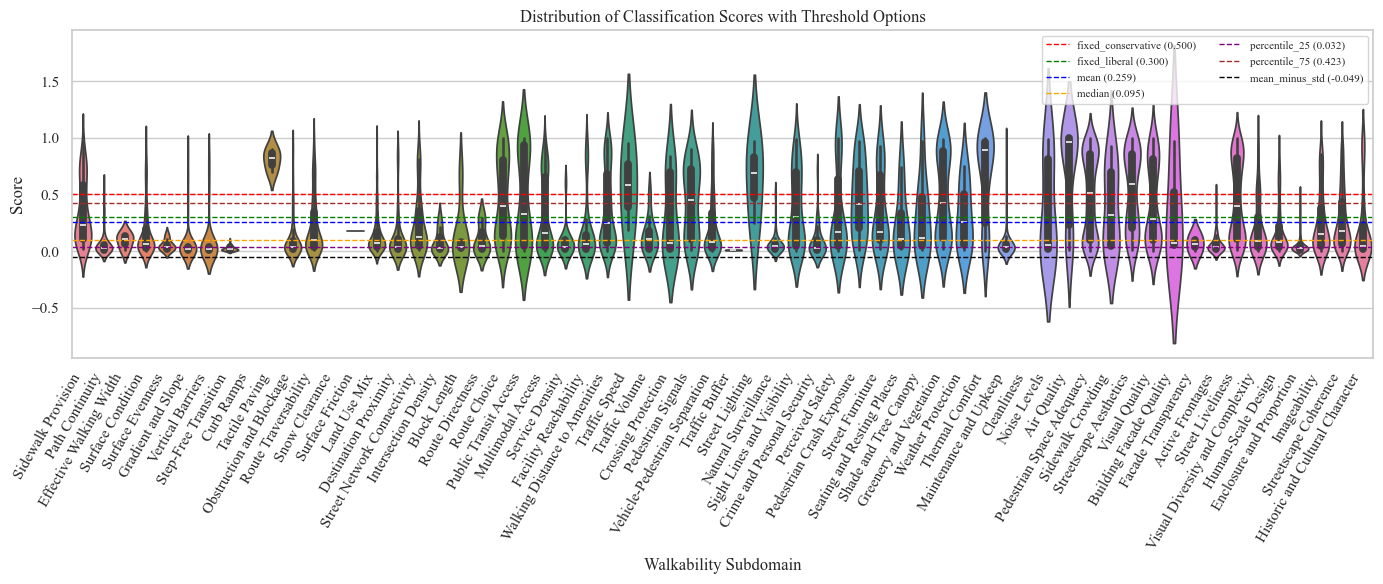

In [9]:
# Calculate statistical thresholds
all_scores = []
for scores in domain_scores.values():
    all_scores.extend([s for s in scores if not np.isnan(s)])

# Calculate various statistical thresholds
thresholds = {
    "fixed_conservative": 0.5,  # Standard fixed threshold
    "fixed_liberal": 0.3,  # More inclusive fixed threshold
    "mean": np.mean(all_scores),  # Average of all scores
    "median": np.median(all_scores),  # Median (50th percentile)
    "percentile_25": np.percentile(all_scores, 25),  # 25th percentile
    "percentile_75": np.percentile(all_scores, 75),  # 75th percentile
    "mean_minus_std": np.mean(all_scores) - np.std(all_scores),  # Lower statistical bound
}

# Display calculated thresholds
print("\n📏 Possible Thresholds:")
for name, value in thresholds.items():
    print(f"  - {name}: {value:.4f}")

# Let's see how many dimensions would be assigned with each threshold
print("\n📊 Subdomains Assigned per Abstract with Different Thresholds:")
for name, threshold in thresholds.items():
    domains_per_abstract = []

    # Iterate through the DataFrame rows
    for _, row in df_filtered.iterrows():
        if 'classification_scores' in row and not pd.isna(row['classification_scores']).any():
            # Count subdomains above threshold
            assigned_domains = sum(1 for score in row['classification_scores'] if score >= threshold)
            domains_per_abstract.append(assigned_domains)

    avg_domains = np.mean(domains_per_abstract) if domains_per_abstract else 0
    print(f"  - {name} (threshold={threshold:.4f}): {avg_domains:.2f} subdomains per abstract")

# Plot threshold lines on the violin plot
plt.figure(figsize=(14, 6))
sns.violinplot(data=scores_df)
plt.xticks(rotation=60, ha="right")
plt.title("Distribution of Classification Scores with Threshold Options")
plt.ylabel("Score")
plt.xlabel("Walkability Subdomain")

# Add horizontal lines for thresholds with different colors
colors = ["red", "green", "blue", "orange", "purple", "brown", "black"]
for (name, threshold), color in zip(thresholds.items(), colors):
    plt.axhline(y=threshold, color=color, linestyle="--", linewidth=1, label=f"{name} ({threshold:.3f})")

plt.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Calibrating the Threshold Against `real.json`

Instead of a fixed threshold picked in advance, this calibrates against the labeled
validation set already used for the inclusion/exclusion screening step
(`real.json`). One caveat matters here: `label == 0` in `real.json` means the article
was *excluded during screening* -- for reasons including not using a sensor at all,
measuring pedestrian behavior instead of a built-environment attribute, or targeting a
different construct (see the adjudication rules used in the screening notebook). It
does **not** mean "does not discuss any walkability dimension" -- an excluded article
can still discuss safety or comfort topically without a sensor measuring it. So
`label == 0` is not treated as a clean negative class here, and precision/WSS are not
computed against it -- only `label == 1` (confirmed sensor-based walkability-dimension
articles) is used, to calibrate recall: the threshold below which a target fraction of
*known-relevant* articles would still receive at least one macro dimension.

This directly targets the concern raised by the 0.5 fixed threshold leaving 75% of the
corpus with no dimension assigned: a gap that large is not fully explained by the
screening step's own false-discovery rate (roughly 40%, from the WSS@95 calibration
used there) -- some of the gap is legitimate (screening false positives correctly
falling out here too), but the rest is the dimension classifier missing dimensions
that are actually present, an artifact of many subdomain labels competing for
probability mass in multi-label zero-shot classification.

In [10]:
# Load the same validation set used for inclusion/exclusion screening.
real_df = pd.read_json("../model/dataset/real.json")

REAL_TEXT_FIELD_CANDIDATES = ["introduction", "contribution", "abstract", "text", "contribution_text"]
REAL_LABEL_FIELD_CANDIDATES = ["label", "is_walkability_related", "walkability", "y", "class"]
POSITIVE_LABEL_VALUES = {1, "1", True, "true", "True", "positive", "Positive", "yes", "Yes",
                         "Sensing of walkability dimension", "sensing of walkability dimension"}

def get_text(record, field_candidates=REAL_TEXT_FIELD_CANDIDATES):
    for field in field_candidates:
        val = record.get(field)
        if isinstance(val, str) and val.strip():
            return val.strip()
    return None

def get_label(record, field_candidates=REAL_LABEL_FIELD_CANDIDATES, positive_values=POSITIVE_LABEL_VALUES):
    for field in field_candidates:
        if field in record and record[field] is not None:
            return 1 if record[field] in positive_values else 0
    return None

real_df["text"] = real_df.apply(lambda r: get_text(r.to_dict()), axis=1)
real_df["label"] = real_df.apply(lambda r: get_label(r.to_dict()), axis=1)
real_df = real_df.dropna(subset=["text", "label"]).reset_index(drop=True)
real_df["label"] = real_df["label"].astype(int)

print(f"Loaded {len(real_df)} labeled records from real.json "
      f"({real_df['label'].sum()} positive / confirmed sensor-based walkability-dimension articles)")

Loaded 100 labeled records from real.json (46 positive / confirmed sensor-based walkability-dimension articles)


In [11]:
# Classify real.json with the same subdomain labels used for the main corpus.
tqdm.pandas(desc="Classifying real.json for dimension calibration")

def classify_and_get_macro_scores(text):
    result = classifier(text, candidate_labels=labels, hypothesis_template="This text is about {}.")
    subdomain_scores = dict(zip(result["labels"], result["scores"]))
    macro_scores = {macro: 0.0 for macro in walkability_dimensions}
    for subdomain, score in subdomain_scores.items():
        for macro_dimension, subdomains in walkability_dimensions.items():
            if subdomain in subdomains:
                macro_scores[macro_dimension] = max(macro_scores[macro_dimension], score)
                break
    return macro_scores

real_df["macro_scores"] = real_df["text"].progress_apply(classify_and_get_macro_scores)

# Best (highest) macro-dimension score per record -- this is what determines whether
# a record would receive at least one dimension at a given threshold.
real_df["best_dimension_score"] = real_df["macro_scores"].apply(lambda s: max(s.values()))

Classifying real.json for dimension calibration: 100%|██████████| 100/100 [29:56<00:00, 17.97s/it]


In [12]:
# Threshold calibration: find the score below which TARGET_DIMENSION_RECALL of the
# label == 1 (confirmed) articles would still receive at least one macro dimension.
# Set to 0.70 by default -- i.e. tolerating up to ~30% of confirmed articles losing
# their dimension assignment to the classifier's own noise, which is the same order
# of magnitude as the ~40% false-discovery rate already accepted at the screening
# step, rather than the much larger, unexplained loss seen at threshold=0.5.
TARGET_DIMENSION_RECALL = 0.70
positive_scores = real_df.loc[real_df["label"] == 1, "best_dimension_score"].sort_values()
n_positive = len(positive_scores)
# Guard: if there are no confirmed positives, avoid iloc out-of-bounds and pick a sensible default.
if n_positive == 0:
    CALIBRATED_THRESHOLD = 0.5
    achieved_recall = 0.0
    fixed_recall = float('nan')
    print("Warning: no confirmed positives found in real.json; ", end='')
    print(" defaulting calibrated threshold to 0.5 and skipping calibration.")
else:
    # Lowest score such that at least TARGET_DIMENSION_RECALL of positives are >= it.
    cutoff_idx = int(np.floor((1 - TARGET_DIMENSION_RECALL) * n_positive))
    cutoff_idx = max(0, min(cutoff_idx, n_positive - 1))
    CALIBRATED_THRESHOLD = float(positive_scores.iloc[cutoff_idx])
    achieved_recall = float((positive_scores >= CALIBRATED_THRESHOLD).mean())
    fixed_recall = float((positive_scores >= 0.5).mean())

print(f"n confirmed positives in real.json: {n_positive}")
print(f"Calibrated threshold: {CALIBRATED_THRESHOLD:.4f}")
print(f"Achieved recall among confirmed positives at this threshold: {achieved_recall:.3f}")
print(f"(compare: fixed_conservative=0.5000 achieved recall {fixed_recall:.3f},among the same confirmed positives)")

n confirmed positives in real.json: 46
Calibrated threshold: 0.1586
Achieved recall among confirmed positives at this threshold: 0.717
(compare: fixed_conservative=0.5000 achieved recall 0.522,among the same confirmed positives)


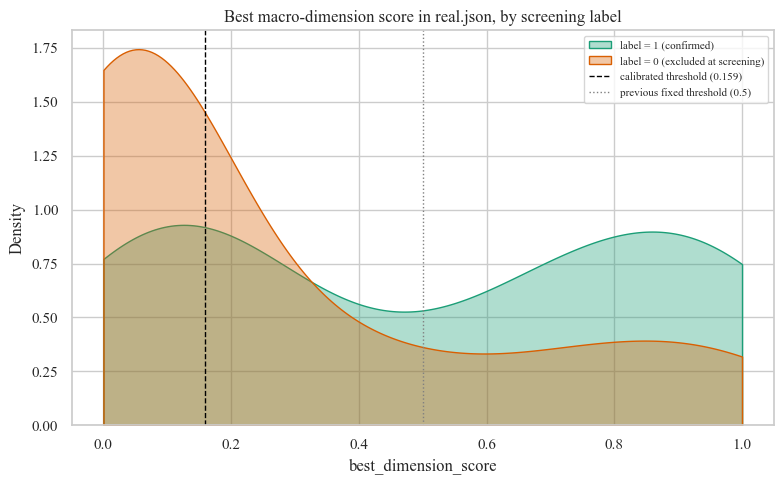

In [13]:
# Diagnostic plot only -- label == 0 is not a clean negative class for this task
# (see note above), so this is not used to pick a precision-optimal cut, just to see
# whether confirmed-positive and excluded articles look different at all.
fig, ax = plt.subplots(figsize=(8, 5))
for label_value, label_name, color in [(1, "label = 1 (confirmed)", "#1b9e77"),
                                        (0, "label = 0 (excluded at screening)", "#d95f02")]:
    subset = real_df.loc[real_df["label"] == label_value, "best_dimension_score"]
    sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35, color=color, label=label_name, clip=(0, 1))
ax.axvline(CALIBRATED_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"calibrated threshold ({CALIBRATED_THRESHOLD:.3f})")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1, label="previous fixed threshold (0.5)")
ax.set_title("Best macro-dimension score in real.json, by screening label")
ax.set_xlabel("best_dimension_score")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

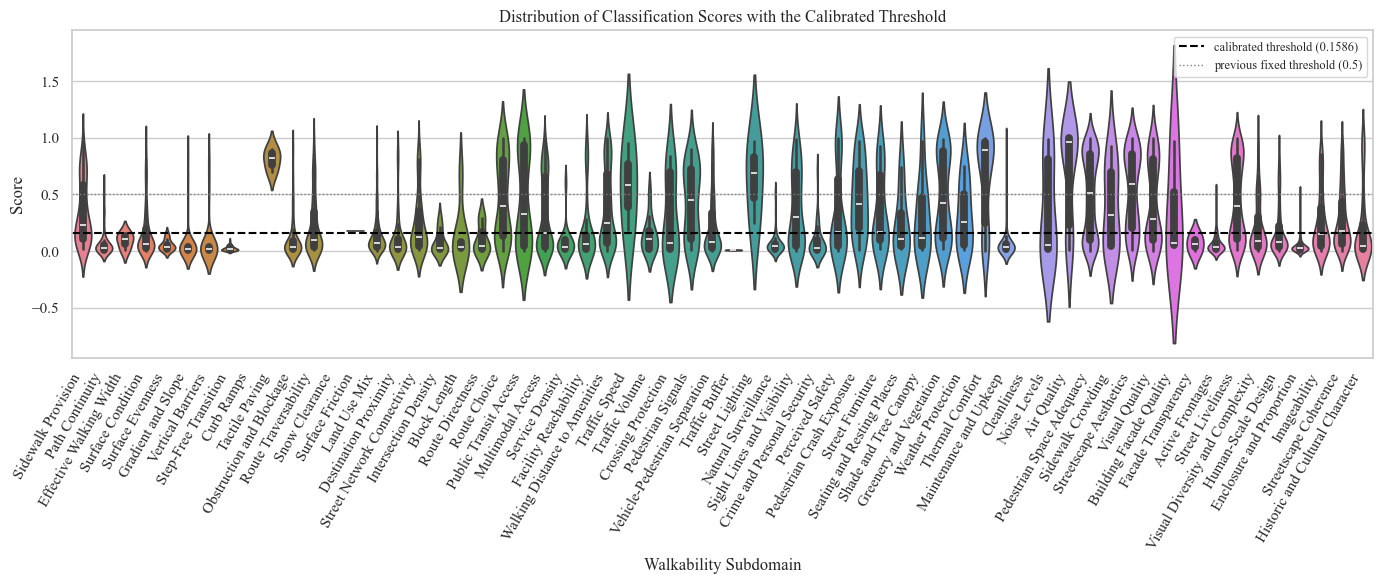

In [14]:
# Same subdomain-level violin plot as before, now with the calibrated threshold
# (from real.json) marked instead of the earlier arbitrary options -- shows whether
# a single threshold is reasonable across all 40 subdomains, or whether some
# subdomains are systematically higher/lower scoring than others.
plt.figure(figsize=(14, 6))
sns.violinplot(data=scores_df)
plt.xticks(rotation=60, ha="right")
plt.title("Distribution of Classification Scores with the Calibrated Threshold")
plt.ylabel("Score")
plt.xlabel("Walkability Subdomain")

plt.axhline(y=CALIBRATED_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
            label=f"calibrated threshold ({CALIBRATED_THRESHOLD:.4f})")
plt.axhline(y=0.5, color="gray", linestyle=":", linewidth=1,
            label="previous fixed threshold (0.5)")

plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## Assign Macro Walkability Dimensions

In [15]:
from collections import Counter

def assign_macro_dimensions_to_df(df, dimension_hierarchy, score_threshold=0.5):
    """
    Assigns each row in the DataFrame to one or more macro walkability dimensions
    (feasibility, accessibility, safety, comfort, pleasurability) based on
    classification scores that exceed a threshold.

    Args:
        df (DataFrame): DataFrame with classification results
        dimension_hierarchy (dict): Walkability dimensions hierarchy dictionary
        score_threshold (float): Minimum score to assign a dimension (default: 0.5)

    Returns:
        DataFrame: Same DataFrame with macro_dimensions column added
    """
    # Create a mapping from subdomain to parent dimension
    subdomain_to_macro = {}
    for macro_dimension, subdomains in dimension_hierarchy.items():
        for subdomain in subdomains:
            subdomain_to_macro[subdomain.lower()] = macro_dimension

    # Create list to store macro dimensions for each row
    all_macro_dimensions = []

    # Process each row in the DataFrame
    for _, row in df.iterrows():
        # Skip if classification data doesn't exist
        if 'classification_labels' not in row or pd.isna(row['classification_labels']).any():
            all_macro_dimensions.append([])
            continue

        # Get classification results
        row_labels = row['classification_labels']
        row_scores = row['classification_scores']

        # Initialize dimension scores dictionary
        dimension_scores = {macro: 0.0 for macro in dimension_hierarchy.keys()}

        # Aggregate scores by macro dimension
        for label, score in zip(row_labels, row_scores):
            label_lower = label.lower()
            # Find the macro dimension for this label
            for subdomain, macro_dimension in subdomain_to_macro.items():
                if subdomain.lower() in label_lower:
                    # Take the highest score for each macro dimension
                    dimension_scores[macro_dimension] = max(
                        dimension_scores[macro_dimension], score
                    )
                    break

        # Keep macro dimensions above the threshold
        assigned = [macro for macro, score in dimension_scores.items() if score >= score_threshold]
        all_macro_dimensions.append(assigned)

    df = df.copy()
    df['macro_dimensions'] = all_macro_dimensions
    return df


# Assign macro walkability dimensions using the threshold calibrated against
# real.json above, instead of a fixed round number. Adjust TARGET_DIMENSION_RECALL
# in the calibration section above (not this value directly) if a different
# confirmed-positive recall trade-off is preferred, then re-run from that cell.
CONFIG_SCORE_THRESHOLD = CALIBRATED_THRESHOLD

df_with_domains = assign_macro_dimensions_to_df(
    df_filtered, walkability_dimensions, score_threshold=CONFIG_SCORE_THRESHOLD
)

# Count how many abstracts fall under each macro dimension
domain_counts = Counter()
for dims in df_with_domains['macro_dimensions']:
    domain_counts.update(dims)

print("\n📊 Dimension Distribution:")
for domain, count in domain_counts.most_common():
    print(f"  - {domain}: {count} abstracts")

avg_domains = np.mean([len(d) for d in df_with_domains['macro_dimensions']])
multi_domain = sum(1 for d in df_with_domains['macro_dimensions'] if len(d) > 1)
zero_domain = sum(1 for d in df_with_domains['macro_dimensions'] if len(d) == 0)
print(f"\nAverage dimensions per abstract: {avg_domains:.2f}")
print(f"Abstracts with multiple dimensions: {multi_domain} ({multi_domain/len(df_with_domains)*100:.2f}%)")
print(f"Abstracts with NO dimension assigned: {zero_domain} ({zero_domain/len(df_with_domains)*100:.2f}%) "
      f"-- compare to 75% at the previous fixed threshold of 0.5")


📊 Dimension Distribution:
  - Pleasurability: 402 abstracts
  - Comfort: 367 abstracts
  - Accessibility: 351 abstracts
  - Feasibility: 208 abstracts
  - Safety: 167 abstracts

Average dimensions per abstract: 1.54
Abstracts with multiple dimensions: 427 (44.11%)
Abstracts with NO dimension assigned: 276 (28.51%) -- compare to 75% at the previous fixed threshold of 0.5


# Visualize Dimension Distribution
Create a bar chart showing how many abstracts were assigned to each macro walkability dimension.

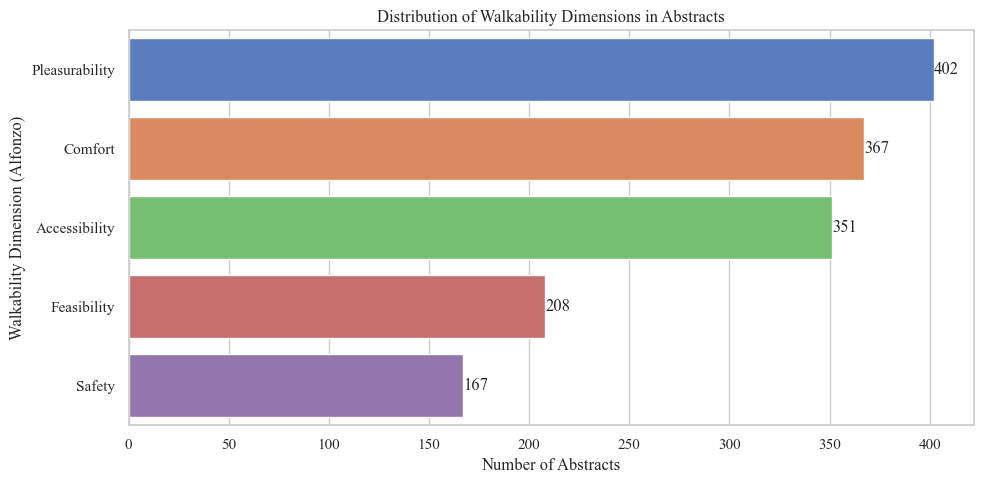

In [16]:
# Plot the distribution of dimensions using a matte color palette
palette = sns.color_palette("muted", n_colors=len(domain_counts))

# Create the dimension and count lists
dimensions_list = [domain for domain, count in domain_counts.most_common()]
counts = [count for domain, count in domain_counts.most_common()]

# Create a bar plot of dimension counts
plt.figure(figsize=(10, 5))
sns.barplot(
    x=counts,
    y=dimensions_list,
    hue=dimensions_list,
    palette=palette,
    legend=False,
)
plt.xlabel("Number of Abstracts")
plt.ylabel("Walkability Dimension (Alfonzo)")
plt.title("Distribution of Walkability Dimensions in Abstracts")

# Add value labels to the end of each bar
for i, count in enumerate(counts):
    plt.text(count + 0.2, i, str(count), va="center")

plt.tight_layout()

# Save the plot
# plt.savefig("../data/06_2_dimension_distribution.png")

plt.show()

# Sensing Modality × Alfonzo Dimension

A quick cross-tabulation of which sensor/technology types (if already classified — e.g. by
João's companion sensor-type notebook) co-occur with which walkability dimensions, mirroring
the crosstab already built in the corpus analysis notebook. Skipped automatically if a
sensor-type column isn't present yet.

In [17]:
SENSOR_COLUMN_CANDIDATES = ["sensor_type", "macro_sensor_types", "technology_type"]
sensor_col = next((c for c in SENSOR_COLUMN_CANDIDATES if c in df_with_domains.columns), None)

if sensor_col is None:
    print("No sensor-type column found yet (expected one of "
          f"{SENSOR_COLUMN_CANDIDATES}) — run João's sensor-type classification notebook "
          "first, merge its output in by DOI, then re-run this cell for the crosstab.")
else:
    exploded = df_with_domains.explode('macro_dimensions').explode(sensor_col)
    crosstab = pd.crosstab(exploded[sensor_col], exploded['macro_dimensions'])
    display(crosstab)

    plt.figure(figsize=(10, 6))
    sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
    plt.title("Sensing Modality × Alfonzo Dimension")
    plt.tight_layout()
    plt.show()

No sensor-type column found yet (expected one of ['sensor_type', 'macro_sensor_types', 'technology_type']) — run João's sensor-type classification notebook first, merge its output in by DOI, then re-run this cell for the crosstab.


# Filter Articles with no Dimension Assigned

In [18]:
no_domain_mask = df_with_domains['macro_dimensions'].apply(lambda x: len(x) == 0)
no_domain_df = df_with_domains[no_domain_mask]

# Remove articles with no assigned macro dimension from the DataFrame
df_with_domains = df_with_domains[~no_domain_mask].copy()
df_with_domains = df_with_domains.reset_index(drop=True)
print(f"\nFiltered DataFrame size: {len(df_with_domains)} articles with assigned dimensions")


Filtered DataFrame size: 692 articles with assigned dimensions


# Save the Results

In [1]:
# Save the DataFrame with macro walkability dimensions to a JSON file
df_with_domains.to_json("../data/06_1_classified_walkability_dimensions.json", orient="records", indent=4)

# Save the dataframe with no assigned dimensions to a JSON file
no_domain_df.to_json("../data/06_1_no_assigned_dimensions.json", orient="records", indent=4)

print(f"Saved:\n  ../data/06_1_classified_walkability_dimensions.json ({len(df_with_domains)} records)"
      f"\n  ../data/06_1_no_assigned_dimensions.json ({len(no_domain_df)} records)")

NameError: name 'df_with_domains' is not defined

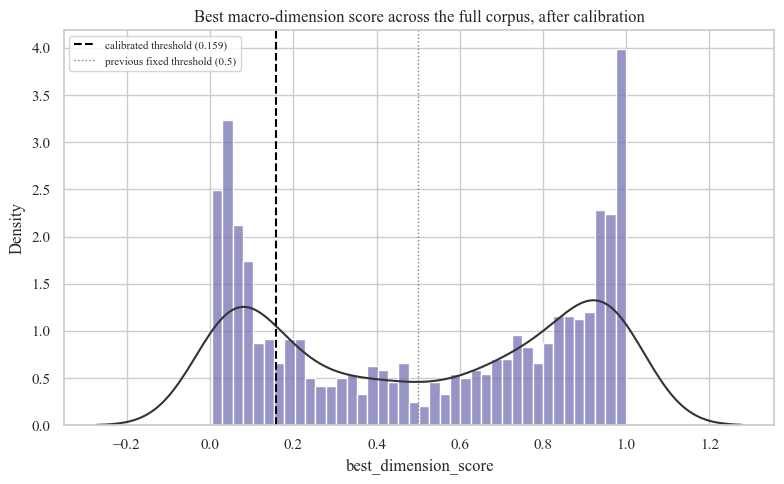

Share of corpus below the calibrated threshold (no dimension assigned): 28.51%


In [20]:
# Post-calibration diagnostic: distribution of each abstract's best macro-dimension
# score across the full corpus (not just real.json), with the calibrated threshold
# marked, so you can see how much of the corpus sits above/below the cutoff.
def get_macro_scores_from_row(row):
    subdomain_scores = dict(zip(row["classification_labels"], row["classification_scores"]))
    macro_scores = {macro: 0.0 for macro in walkability_dimensions}
    for subdomain, score in subdomain_scores.items():
        for macro_dimension, subdomains in walkability_dimensions.items():
            if subdomain in subdomains:
                macro_scores[macro_dimension] = max(macro_scores[macro_dimension], score)
                break
    return macro_scores

corpus_best_scores = df_filtered.apply(
    lambda row: max(get_macro_scores_from_row(row).values()), axis=1
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(corpus_best_scores, bins=40, ax=ax, color="#7570b3", stat="density")
sns.kdeplot(corpus_best_scores, ax=ax, color="#333333", linewidth=1.5)
ax.axvline(CONFIG_SCORE_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"calibrated threshold ({CONFIG_SCORE_THRESHOLD:.3f})")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1, label="previous fixed threshold (0.5)")
ax.set_title("Best macro-dimension score across the full corpus, after calibration")
ax.set_xlabel("best_dimension_score")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Share of corpus below the calibrated threshold (no dimension assigned): "
      f"{(corpus_best_scores < CONFIG_SCORE_THRESHOLD).mean()*100:.2f}%")